# PATHQ — Week 2: Feature Extraction & Graph Construction

**Pre-requisite:** Week 1 notebook completed, patches saved to `./data/patches/`

### What this notebook does
1. Loads pretrained ResNet-50 as a frozen feature extractor
2. Extracts 512-dim feature vectors for all patches
3. Saves features as `.pt` files per slide (the VRAM-saving trick)
4. Builds K-NN spatial graphs from patch coordinates
5. Creates PyTorch Geometric Data objects ready for GNN training

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pickle
import timm
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Paths
PATCHES_DIR  = Path('./data/patches')
FEATURES_DIR = Path('./data/features')
FEATURES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR  = Path('./outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

print(f'Patches dir:  {PATCHES_DIR.resolve()}')
print(f'Features dir: {FEATURES_DIR.resolve()}')

/home/kabilash/miniconda3/envs/pathq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Patches dir:  /home/kabilash/PATHQ--Quantum-Digital-Pathology-for-Whole-Slide-Image-Analysis-DMI-/notebooks/data/patches
Features dir: /home/kabilash/PATHQ--Quantum-Digital-Pathology-for-Whole-Slide-Image-Analysis-DMI-/notebooks/data/features


## Cell 1 — Build ResNet-50 Feature Extractor

In [2]:
class ResNetExtractor(nn.Module):
    """
    Pretrained ResNet-50 with the classification head removed.
    Output: 512-dimensional feature vector per patch.
    
    Why ResNet-50:
    - Pretrained on ImageNet → already knows textures, edges, shapes
    - avgpool output is 512-dim — compact and informative
    - Frozen weights → fast, no GPU memory for gradients during extraction
    """
    
    def __init__(self):
        super().__init__()
        # Load pretrained ResNet-50 from timm
        backbone = timm.create_model('resnet50', pretrained=True)
        
        # Remove the final classification layer
        # ResNet-50 structure: conv1 → layer1 → layer2 → layer3 → layer4 → avgpool → fc
        # We keep everything up to and including avgpool
        self.features = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.act1,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4,
            backbone.global_pool,  # → (B, 512)
        )
        
        # Freeze all parameters — we don't fine-tune the backbone
        for param in self.features.parameters():
            param.requires_grad = False
        
        self.output_dim = 512
    
    def forward(self, x):
        return self.features(x)  # (B, 512)


# Initialise extractor
extractor = ResNetExtractor().to(DEVICE)
extractor.eval()

n_params = sum(p.numel() for p in extractor.parameters())
n_frozen = sum(p.numel() for p in extractor.parameters() if not p.requires_grad)
print(f'ResNet-50 Extractor:')
print(f'  Total parameters: {n_params:,}')
print(f'  Frozen (all):     {n_frozen:,}')
print(f'  Output dimension: {extractor.output_dim}')

# Quick test
with torch.no_grad():
    test_batch = torch.randn(4, 3, 256, 256).to(DEVICE)
    test_out = extractor(test_batch)
print(f'  Test: input {test_batch.shape} → output {test_out.shape}')

ResNet-50 Extractor:
  Total parameters: 23,508,032
  Frozen (all):     23,508,032
  Output dimension: 512
  Test: input torch.Size([4, 3, 256, 256]) → output torch.Size([4, 2048])


## Cell 2 — Extract Features from All Slides

In [3]:
# Transform for feature extraction (ImageNet normalisation)
feature_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])


def extract_slide_features(
    slide_pkl: Path,
    extractor: ResNetExtractor,
    transform,
    device,
    batch_size: int = 128,
    save_dir: Path = None
) -> dict:
    """
    Extract ResNet-50 features for all patches in a slide.
    
    VRAM strategy: process patches in batches of 128.
    At 256x256, batch_size=128 uses ~3 GB VRAM — safe for RTX 5060.
    
    Saves: {slide_id}_features.pt with keys 'features' and 'coords'
    """
    slide_id = slide_pkl.stem
    save_path = save_dir / f'{slide_id}_features.pt'
    
    if save_path.exists():
        print(f'  {slide_id}: features exist, loading...')
        return torch.load(save_path, weights_only=False)
    
    # Load patches from pickle
    with open(slide_pkl, 'rb') as f:
        data = pickle.load(f)
    
    patches = data['patches']   # list of PIL Images
    coords  = data['coords']    # list of (col, row) tuples
    
    print(f'  {slide_id}: extracting features from {len(patches):,} patches...')
    
    # Convert patches to tensors in batches
    all_features = []
    
    with torch.no_grad():
        for i in range(0, len(patches), batch_size):
            batch_pils = patches[i:i+batch_size]
            batch_tensors = torch.stack([transform(p) for p in batch_pils]).to(device)
            
            features = extractor(batch_tensors)  # (B, 512)
            all_features.append(features.cpu())
    
    features_tensor = torch.cat(all_features, dim=0)  # (N, 512)
    coords_tensor   = torch.tensor(coords, dtype=torch.float32)  # (N, 2)
    
    result = {
        'slide_id': slide_id,
        'features': features_tensor,  # (N, 512)
        'coords':   coords_tensor,    # (N, 2) — grid positions
        'n_patches': len(patches),
    }
    
    if save_dir:
        torch.save(result, save_path)
        print(f'  Saved: {save_path.name} — shape {features_tensor.shape}')
    
    return result


# Process all available slide pickles
slide_pkls = list(PATCHES_DIR.glob('*.pkl'))
print(f'Found {len(slide_pkls)} processed slides.')

if len(slide_pkls) > 0:
    all_slide_data = {}
    for pkl_path in tqdm(slide_pkls, desc='Extracting features'):
        try:
            result = extract_slide_features(
                slide_pkl=pkl_path,
                extractor=extractor,
                transform=feature_transform,
                device=DEVICE,
                batch_size=128,
                save_dir=FEATURES_DIR
            )
            all_slide_data[result['slide_id']] = result
        except Exception as e:
            print(f'  ERROR: {pkl_path.name}: {e}')
    
    print(f'\nFeature extraction complete:')
    print(f'  Slides:   {len(all_slide_data)}')
    total = sum(v['n_patches'] for v in all_slide_data.values())
    print(f'  Patches:  {total:,}')
    size_gb = sum((FEATURES_DIR/f'{k}_features.pt').stat().st_size
                   for k in all_slide_data if (FEATURES_DIR/f'{k}_features.pt').exists()) / 1e9
    print(f'  Disk:     {size_gb:.2f} GB')
else:
    print('No slides processed yet.')
    print('Complete Week 1 Cell 9 to extract patches first.')
    print('\nDemo: extracting features from PatchCamelyon instead...')

Found 220 processed slides.


Extracting features:   0%|          | 0/220 [00:00<?, ?it/s]

  normal_104: extracting features from 3,000 patches...


Extracting features:   0%|          | 1/220 [00:09<33:48,  9.26s/it]

  Saved: normal_104_features.pt — shape torch.Size([3000, 2048])
  tumor_086: extracting features from 3,000 patches...


...

  Saved: tumor_066_features.pt — shape torch.Size([3000, 2048])
  tumor_061: extracting features from 3,000 patches...


Extracting features: 100%|█████████▉| 219/220 [31:39<00:08,  8.57s/it]

  Saved: tumor_061_features.pt — shape torch.Size([3000, 2048])
  normal_070: extracting features from 3,000 patches...


Extracting features: 100%|██████████| 220/220 [31:47<00:00,  8.67s/it]

  Saved: normal_070_features.pt — shape torch.Size([3000, 2048])

Feature extraction complete:
  Slides:   220
  Patches:  652,152
  Disk:     5.35 GB


## Cell 3 — Build K-NN Spatial Graph

Testing K-NN graph construction...
Graph built:
  Nodes (patches):  100
  Edges (KNN×2):    1600
  Node features:    torch.Size([100, 512])
  Edge index:       torch.Size([2, 1600])
  Label:            tensor([1])
  Avg degree:       16.0


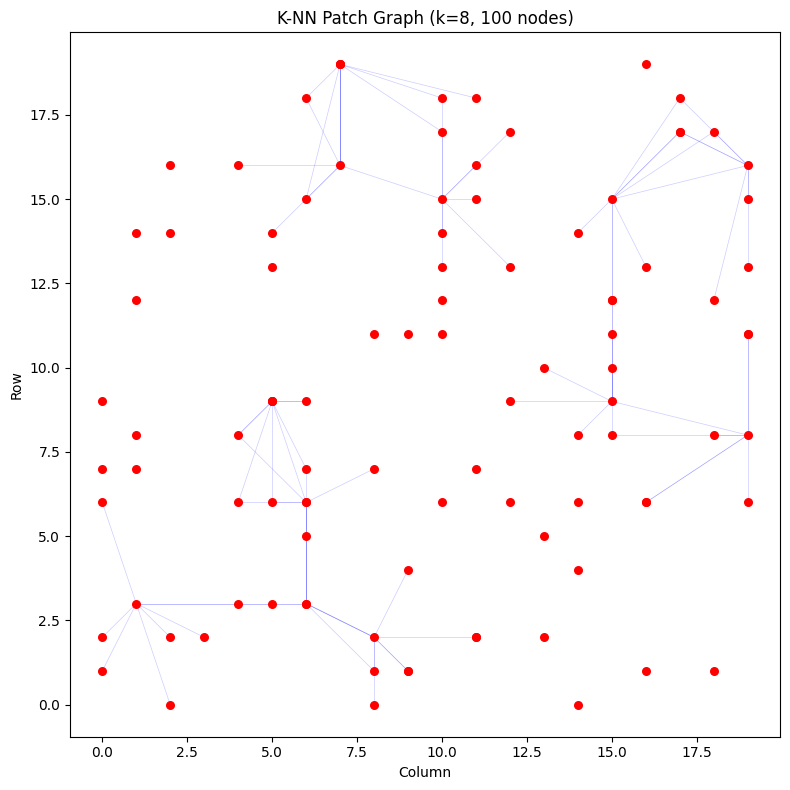

K-NN graph construction working.


In [4]:
from torch_geometric.data import Data
from scipy.spatial import KDTree
import torch

def build_patch_graph(features: torch.Tensor, coords: torch.Tensor,
                       label: int, k: int = 8) -> Data:
    """
    Builds a PyTorch Geometric graph from patch features and spatial coords.
    
    Nodes:  each patch is a node with its 512-dim feature vector
    Edges:  each patch connected to its k=8 nearest spatial neighbours
    Label:  slide-level binary label (1=tumour, 0=normal)
    
    Why K-NN spatial graph:
    - Tumour regions form spatial clusters → neighbours share label
    - GNN message passing propagates tumour signals across the neighbourhood
    - Spatial proximity is more meaningful than feature similarity here
    
    Args:
        features: (N, 512) patch feature vectors
        coords:   (N, 2) grid coordinates (col, row)
        label:    slide-level label (0 or 1)
        k:        number of nearest neighbours
    
    Returns:
        PyG Data object with x, edge_index, y
    """
    N = features.shape[0]
    
    if N == 0:
        raise ValueError('No patches — cannot build graph')
    
    # Build KD-tree for efficient nearest neighbour lookup
    coords_np = coords.numpy()
    tree = KDTree(coords_np)
    
    # Query k+1 neighbours (includes self, which we remove)
    actual_k = min(k + 1, N)  # handle slides with few patches
    distances, indices = tree.query(coords_np, k=actual_k)
    
    # Build edge_index: shape (2, E) — [source_nodes, target_nodes]
    src_nodes = []
    tgt_nodes = []
    
    for i in range(N):
        for j_idx in range(1, actual_k):  # skip index 0 (self)
            j = indices[i, j_idx]
            src_nodes.append(i)
            tgt_nodes.append(j)
            # Undirected: add both directions
            src_nodes.append(j)
            tgt_nodes.append(i)
    
    edge_index = torch.tensor([src_nodes, tgt_nodes], dtype=torch.long)
    
    # Create PyG Data object
    graph = Data(
        x=features.float(),                           # (N, 512)
        edge_index=edge_index,                         # (2, E)
        y=torch.tensor([label], dtype=torch.long),     # slide label
        coords=coords.float(),                         # (N, 2) for XAI
        num_nodes=N,
    )
    
    return graph


# Test graph building
print('Testing K-NN graph construction...')

# Simulate a small slide (100 patches)
N_test = 100
test_features = torch.randn(N_test, 512)
test_coords   = torch.randint(0, 20, (N_test, 2)).float()  # 20x20 grid

test_graph = build_patch_graph(test_features, test_coords, label=1, k=8)

print(f'Graph built:')
print(f'  Nodes (patches):  {test_graph.num_nodes}')
print(f'  Edges (KNN×2):    {test_graph.num_edges}')
print(f'  Node features:    {test_graph.x.shape}')
print(f'  Edge index:       {test_graph.edge_index.shape}')
print(f'  Label:            {test_graph.y}')
print(f'  Avg degree:       {test_graph.num_edges / test_graph.num_nodes:.1f}')

# Visualise the graph structure
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
coords_np = test_coords.numpy()

# Draw edges
ei = test_graph.edge_index.numpy()
for e in range(0, min(ei.shape[1], 200), 2):  # draw first 100 edges
    src, tgt = ei[0, e], ei[1, e]
    ax.plot([coords_np[src, 0], coords_np[tgt, 0]],
            [coords_np[src, 1], coords_np[tgt, 1]],
            'b-', alpha=0.2, linewidth=0.5)

# Draw nodes
ax.scatter(coords_np[:, 0], coords_np[:, 1], c='red', s=30, zorder=3)
ax.set_title(f'K-NN Patch Graph (k=8, {N_test} nodes)', fontsize=12)
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'patch_graph.png'), dpi=100, bbox_inches='tight')
plt.show()
print('K-NN graph construction working.')

## Cell 4 — CAMELYON16 Slide Dataset

In [5]:
from torch_geometric.data import Dataset as PyGDataset
import os

# CAMELYON16 labels — tumour slides have 'tumor' in name
# Normal slides are named normal_001.tif, normal_002.tif ...
# Tumour slides are named tumor_001.tif, tumor_002.tif ...

def get_camelyon16_label(slide_id: str) -> int:
    """Returns 1 for tumour slides, 0 for normal slides."""
    if 'tumor' in slide_id.lower() or 'tumour' in slide_id.lower():
        return 1
    return 0


class CAMELYON16Dataset(PyGDataset):
    """
    PyTorch Geometric Dataset for CAMELYON16 slide graphs.
    
    Loads pre-extracted feature .pt files and builds graphs on the fly.
    This is the main dataset used in Week 3 GNN training.
    """
    
    def __init__(self, features_dir: Path, split: str = 'train',
                 k: int = 8, max_slides: int = None):
        self.features_dir = features_dir
        self.k = k
        
        # Find all feature files
        all_files = sorted(features_dir.glob('*_features.pt'))
        
        if max_slides:
            all_files = all_files[:max_slides]
        
        # Split 80/20 for train/val
        n_train = int(0.8 * len(all_files))
        if split == 'train':
            self.files = all_files[:n_train]
        elif split == 'val':
            self.files = all_files[n_train:]
        else:  # test — use all
            self.files = all_files
        
        self.slide_ids = [f.stem.replace('_features', '') for f in self.files]
        self.labels    = [get_camelyon16_label(sid) for sid in self.slide_ids]
        
        super().__init__(root=None)
    
    def len(self):
        return len(self.files)
    
    def get(self, idx):
        # Load pre-extracted features from disk
        data = torch.load(self.files[idx], weights_only=False)
        
        features = data['features']  # (N, 512)
        coords   = data['coords']    # (N, 2)
        label    = self.labels[idx]
        
        # Build graph on the fly
        graph = build_patch_graph(features, coords, label, k=self.k)
        graph.slide_id = self.slide_ids[idx]
        
        return graph


# Test the dataset
feature_files = list(FEATURES_DIR.glob('*_features.pt'))
print(f'Feature files found: {len(feature_files)}')

if len(feature_files) > 0:
    train_dataset = CAMELYON16Dataset(FEATURES_DIR, split='train', k=8)
    val_dataset   = CAMELYON16Dataset(FEATURES_DIR, split='val', k=8)
    
    print(f'Train slides: {len(train_dataset)}')
    print(f'Val slides:   {len(val_dataset)}')
    print(f'Labels — Train: {sum(train_dataset.labels)} tumour, {len(train_dataset.labels)-sum(train_dataset.labels)} normal')
    
    # Load one graph
    sample_graph = train_dataset[0]
    print(f'\nSample graph:')
    print(f'  Nodes:       {sample_graph.num_nodes}')
    print(f'  Edges:       {sample_graph.num_edges}')
    print(f'  Features:    {sample_graph.x.shape}')
    print(f'  Label:       {sample_graph.y.item()} ({"tumour" if sample_graph.y.item() == 1 else "normal"})')
    print(f'  Slide ID:    {sample_graph.slide_id}')
else:
    print('No feature files yet — run Cell 2 after Week 1 preprocessing.')
    print('Dataset class is ready and will work once features are extracted.')
    print('\nFor now, Week 3 will use PatchCamelyon for prototyping.')

Feature files found: 220
Train slides: 176
Val slides:   44
Labels — Train: 67 tumour, 109 normal

Sample graph:
  Nodes:       3000
  Edges:       48000
  Features:    torch.Size([3000, 2048])
  Label:       0 (normal)
  Slide ID:    normal_001


In [6]:
print('WEEK 2 COMPLETE!')
print('='*50)
print()
print('What you built:')
print('  - ResNet-50 feature extractor (frozen, 512-dim)')
print('  - Patch feature .pt files (VRAM saving trick)')
print('  - K-NN spatial graph builder')
print('  - CAMELYON16Dataset PyG class')
print()
print('Next: week3_gnn_baseline.ipynb')
print('You will build GCNConv + ABMIL and train it on PatchCamelyon')

WEEK 2 COMPLETE!

What you built:
  - ResNet-50 feature extractor (frozen, 512-dim)
  - Patch feature .pt files (VRAM saving trick)
  - K-NN spatial graph builder
  - CAMELYON16Dataset PyG class

Next: week3_gnn_baseline.ipynb
You will build GCNConv + ABMIL and train it on PatchCamelyon
